In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=0.6753127/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

To predict the column density of the $i$-th ion of an element $X$ within a single gas phase (characterized by $n_{\mathrm{H}}$,) we first need to find the total hydrogen column density, as follows -

$$N_{\mathrm{H}} = N_{\mathrm{HI}} \times \frac{n_{\mathrm{H}}}{n_{\mathrm{HI}}} = \frac{N_{\mathrm{HI}}}{f_{\mathrm{HI}}}$$

Then, we can obtain the total column density of $X$ using the abundance [X/H] -

$$N_{\mathrm{X}} = N_{\mathrm{H}} \times 10^{\mathrm{[X/H]}}$$

Finally, we can get the column density of the ion $X_i$ using the ionization fraction $f_{X_i} = n_{\mathrm{X_i}}/n_{\mathrm{X}}$ -

$$N_{\mathrm{X_i}} = f_{X_i} \times N_{\mathrm{X}}$$

Putting all of this together -

$$N_{\mathrm{X_i}} = N_{\mathrm{HI}} \times \frac{f_{X_i}}{f_{\mathrm{HI}}} \times 10^{[\mathrm{X/H}]}$$

It is helpful to remember that ionizing fractions (at least in the low metallicity regime) only depend on the ionization parameter $U = n_{\gamma}/ n_{\mathrm{H}}$, so that -

$$\boxed{N_{\mathrm{X_i}} (N_{\mathrm{HI}}, U, [\mathrm{X/H}]) = N_{\mathrm{HI}} \times \frac{f_{X_i}}{f_{\mathrm{HI}}} (U) \times 10^{[\mathrm{X/H}]}}$$

In [15]:
logN_HI_test = 15.44
log_hdens_test = -3.4
log_metals_test = -0.6

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp)

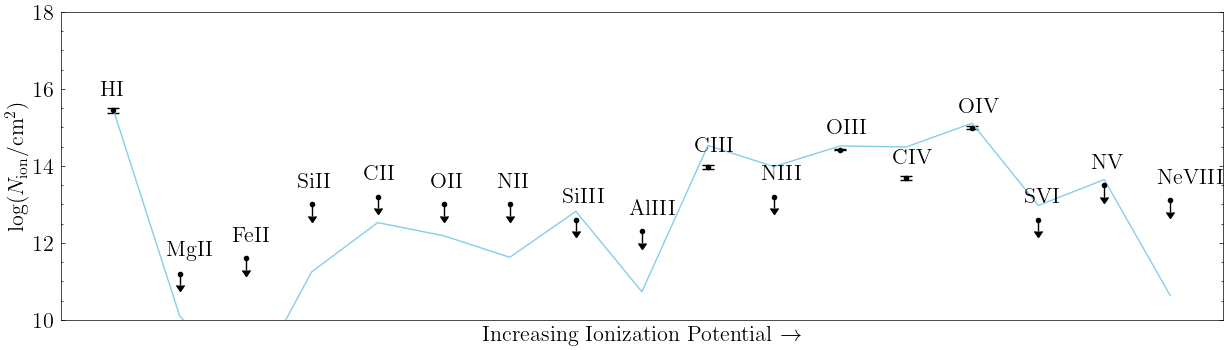

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

Get column density ratios

In [54]:
gen_logN_ratio_str(logN_dict['CII'], logN_dict['CIII'])

'<-0.77, 0.15'

In [55]:
logN_ratio_dict = {'OIV/SVI': '>2.4, 0.2',
                   'OII/OIII': '<-1.4, 0.1',
                   'OIV/OIII': '0.57, -0.04, 0.06',  
                   'CII/CIII': '<-0.8, 0.2',
                   'CIV/CIII': '-0.29, -0.08, 0.08'
                  }

We had the expression -

$$N_{\mathrm{X_i}} = N_{\mathrm{HI}} \times \frac{f_{X_i}}{f_{\mathrm{HI}}} \times 10^{[\mathrm{X/H}]}$$

So the column density ratio of two ions $X_i$ and $Y_j$ will be given by -

$$\boxed{\frac{N_{\mathrm{X_i}}}{N_{\mathrm{Y_j}}} = \frac{f_{X_i}}{f_{Y_j}} \times 10^{[\mathrm{X/Y}]}}$$

If we assume [X/Y]=0 (as we can for $\alpha$ elements usually, or at least for oxygen and sulphur), then the column density ratio will just be governed by the gas density. 

We can test the hypothesis of the observed column density distribution of ions being explainable by a single gas phase by plotting observed column density ratios and inferring correpsonding gas density ranges. If we can get a consistent range of gas densities, then a single phase solution is feasible. If this test fails, then there are two possibilities -

1. If the ion pair used to infer gas density involves different elements, then their abundance pattern may not be similar (i.e. [X/Y] is not zero)

2. A single gas phase is not sufficient to explain the observed column densities of ions

(-5.0, 5.0)

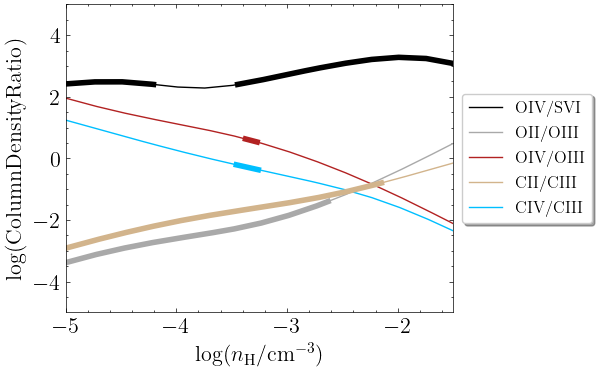

In [56]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

# Fit gas density

In [59]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [60]:
logN_ratio_dict

{'OIV/SVI': '>2.4, 0.2',
 'OII/OIII': '<-1.4, 0.1',
 'OIV/OIII': '0.57, -0.04, 0.06',
 'CII/CIII': '<-0.8, 0.2',
 'CIV/CIII': '-0.29, -0.08, 0.08'}

In [61]:
pos = np.array(-3.35) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [62]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [63]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [09:15<00:00,  1.11s/it]


In [64]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

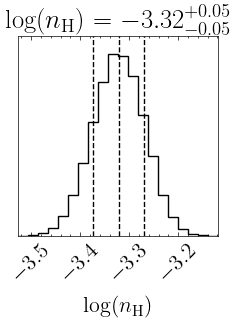

In [65]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [67]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [68]:
logN_offset = 14.42-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate the C/O ratio

In [72]:
logN_CIII_obs = np.random.normal(loc=13.97, scale=0.05, size=len(flat_samples_hdens))
logN_CIV_obs = np.random.normal(loc=13.68, scale=0.05, size=len(flat_samples_hdens))

In [82]:
C_O_dist_CIII = logN_CIII_obs-(logN_offset+species_logN_interp['C+2'](grid_points_hdens))
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = np.concatenate((C_O_dist_CIII, C_O_dist_CIV))

In [87]:
(np.round(np.median(C_O_dist), 2), 
np.round(np.percentile(C_O_dist, 100*(1-cdf_1sig))-np.median(C_O_dist), 2),
np.round(np.percentile(C_O_dist, 100*cdf_1sig)-np.median(C_O_dist), 2))

(-0.56, -0.06, 0.07)

Plot models

In [83]:
logN_dict = {#'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            #'NII':'<13.0',
            #'NIII':'<13.2',
            #'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            #'NeVIII':'<13.1',
            'MgII':'<11.2',
            #'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            #'SVI':'<12.6',
            'FeII':'<11.6'}

In [84]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

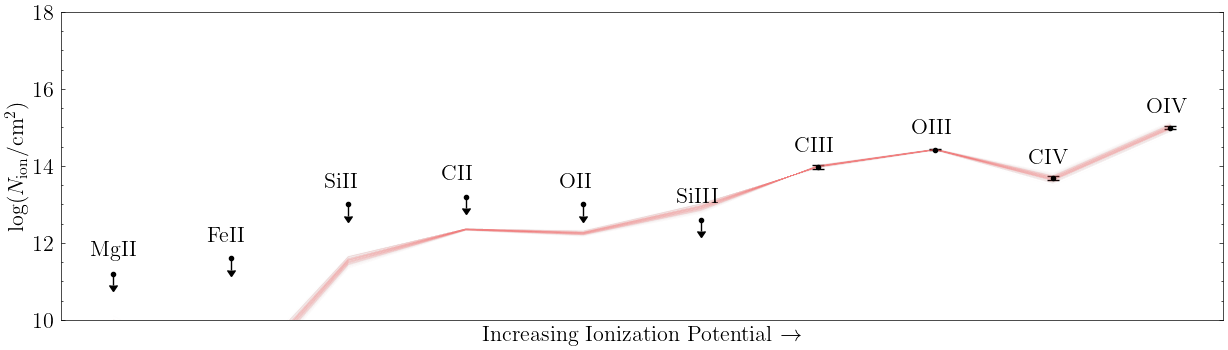

In [86]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.05)

# Oxygen + Sulphur fit

In [21]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original prior function on the full set of parameters
    return log_prior(params_full)

In [22]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [23]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [24]:
ions_oxy_sul = ['OII', 'OIII', 'OIV', 'SVI']

In [25]:
logN_dict_oxy_sul = {ion: logN_dict[ion] for ion in ions_oxy_sul}

In [26]:
logN_dict_oxy_sul

{'OII': '<13.0',
 'OIII': '14.42, -0.02, +0.02',
 'OIV': '14.99, -0.04, +0.06',
 'SVI': '<12.6'}

In [27]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [28]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_sul, species_logN_interp)
)

In [29]:
#sampler.run_mcmc(pos, 500, progress=True);

In [30]:
#flat_samples_oxy_sul = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals'])
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

flat_samples_oxy_sul = pd.read_csv(savedir+'oxy_sul_solar_flat.csv')

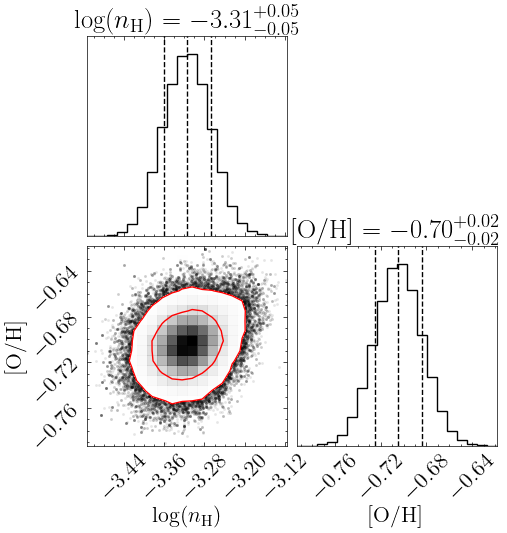

In [31]:
fig = corner.corner(
    flat_samples_oxy_sul.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Plot expected column density ratios for derived metallicity

(-5.0, 1.5)

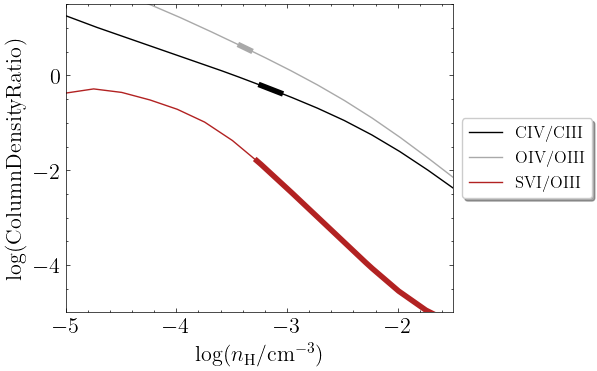

In [32]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict, 
                logN_HI_ref=logN_HI_test, log_metals_ref=-0.7)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 1.5)

We'd expect the CIV to be slightly overproduced at the best fit density; worth allowing non-solar C/O for a single phase and seeing if affects the best density/ metallicity. Now plot the best models.

In [33]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

In [34]:
sample_indices_oxy_sul = np.random.randint(low=0, high=len(flat_samples_oxy_sul), size=200)

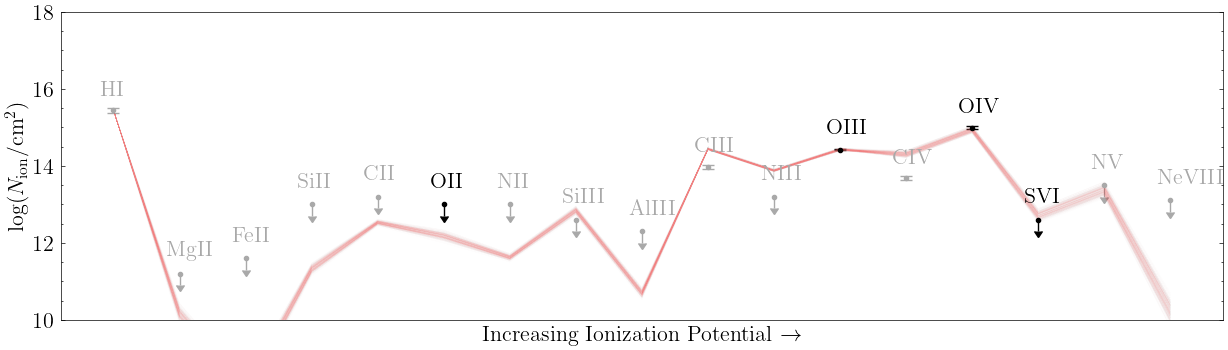

In [35]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII', 'CIII', 
                                                         'CIV', 'NII', 'NIII', 
                                                         'NV', 
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 
                                                         'FeII', 'OVI'])

for i in range(len(sample_indices_oxy_sul)):
    
    idx = sample_indices_oxy_sul[i]
    flat_samples_row = flat_samples_oxy_sul.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.33 \pm 0.03$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -0.66 \pm 0.02$')

#plt.savefig(savedir+'z=0_67532051_cloudy_oxy_sul.pdf', dpi=300)

Plot the posterior for cloud size

In [39]:
#flat_samples_oxy_sul['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
#                                                            flat_samples_oxy_sul.iloc[i]['log_hdens'],
#                                                            flat_samples_oxy_sul.iloc[i]['log_metals']])[0]
#                                               for i in range(len(flat_samples_oxy_sul))]

In [40]:
#flat_samples_oxy_sul['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy_sul['logN_HII'])/10**flat_samples_oxy_sul['log_hdens'])*3.24078e-19*1e-3

In [41]:
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

In [42]:
l_med = np.median(flat_samples_oxy_sul['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy_sul['cloud_size_kpc'],84)

In [43]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(9.36314085414645, 1.9061283323764773, 2.3758813960689817)

Text(0, 0.5, 'Probability Density')

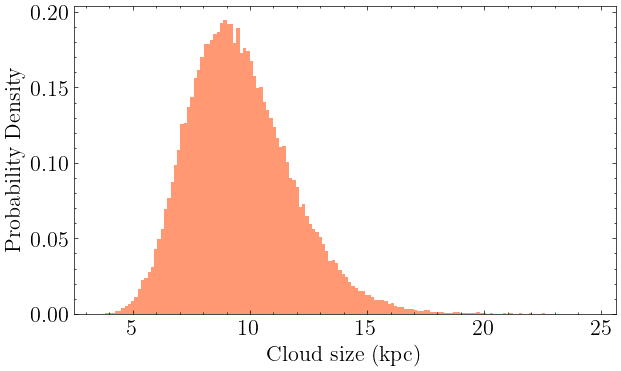

In [45]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy_sul['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(12, 0.26, s=r'$\log N_{\mathrm{HI}} = 15.40 \pm 0.06$')
#ax.text(12, 0.22, s=r'$l = 9 \pm 1 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

# Oxygen + Sulphur + Carbon

In [41]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals, C_O = params
    
    # Get abundance for carbon
    C_H = log_metals + C_O
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if log_hdens_min<log_hdens<log_hdens_max and log_metals_min<log_metals<log_metals_max and log_metals_min<C_H<log_metals_max:
        return 0.0
    return -np.inf

In [42]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals, C_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {'C': C_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [43]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [44]:
ions_oxy_sul_carb = ['OII', 'OIII', 'OIV', 'SVI', 'CIII', 'CIV']

In [45]:
logN_dict_oxy_sul_carb = {ion: logN_dict[ion] for ion in ions_oxy_sul_carb}

In [46]:
logN_dict_oxy_sul_carb

{'OII': '<13.0',
 'OIII': '14.42, -0.02, +0.02',
 'OIV': '14.99, -0.04, +0.06',
 'SVI': '<12.6',
 'CIII': '13.97, -0.05, +0.05',
 'CIV': '13.68, -0.06, +0.06'}

In [47]:
pos = np.array([log_hdens_test, log_metals_test, -0.4]) + 1e-4 * np.random.randn(500, 3)
nwalkers, ndim = pos.shape

In [48]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy_sul_carb, species_logN_interp)
)

In [49]:
sampler.run_mcmc(pos, 500, progress=True)

100%|███████████████████████████████████| 500/500 [05:21<00:00,  1.56it/s]


State([[-3.28855759 -0.74069656 -0.50129678]
 [-3.32693156 -0.68363822 -0.56890643]
 [-3.25654211 -0.71521076 -0.48942145]
 ...
 [-3.30488692 -0.70680771 -0.53097802]
 [-3.37796538 -0.72565968 -0.56599576]
 [-3.27326879 -0.698146   -0.45446109]], log_prob=[ -7.1809752   -6.96260372  -5.80414147  -6.54131999  -8.37914132
  -6.14884821  -6.8821715   -8.10151071  -8.46191894  -7.22841786
  -6.73567348  -6.14191895  -7.06596     -6.34953795  -7.96080937
  -6.63476846  -5.66676451  -5.90526027  -6.1712271   -7.61312833
  -6.6421767   -6.49514722  -6.01895035  -5.97995399  -5.99158687
 -10.14890049  -9.87180302  -5.98383347  -6.7720334   -6.88449135
  -8.93485396  -8.21024706  -5.87682275  -6.17646641  -9.0315355
  -7.10747439  -5.7781125   -6.28390123  -6.01129126  -9.31713895
  -7.75658759  -6.98621577  -7.96545466  -6.65726841  -6.74214594
  -7.28265355  -7.35914784  -6.65972305  -7.33662496  -8.84221545
  -7.49918759 -11.52799236  -6.53911535 -10.25452373  -6.85924641
  -6.22168402  -7.5

In [50]:
flat_samples_oxy_sul_carb = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens', 'log_metals', 'C_O'])
flat_samples_oxy_sul_carb.to_csv(savedir+'oxy_sul_carb_subsolar_flat.csv', index=False)

#flat_samples_oxy_sul_carb = pd.read_csv(savedir+'oxy_sul_carb_subsolar_flat.csv')

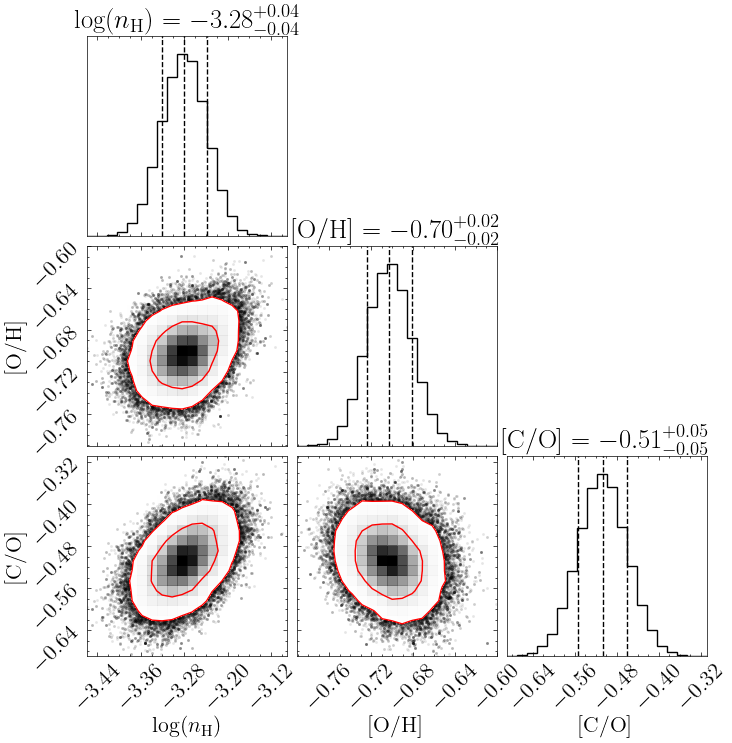

In [51]:
fig = corner.corner(
    flat_samples_oxy_sul_carb, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', r'$[\mathrm{C/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [52]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

In [53]:
sample_indices_oxy_sul_carb = np.random.randint(low=0, high=len(flat_samples_oxy_sul_carb), size=200)

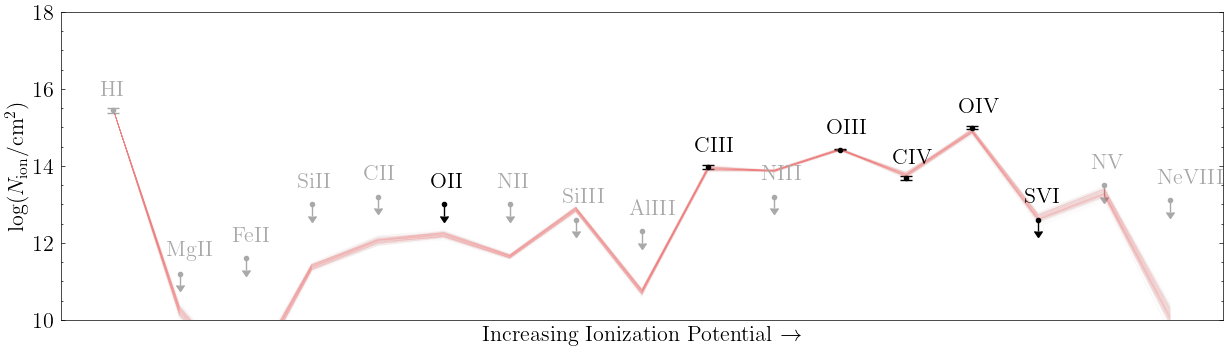

In [54]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 'CII',
                                                         'NII', 'NIII', 
                                                         'NV', 
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 
                                                         'FeII', 'OVI'])

for i in range(len(sample_indices_oxy_sul_carb)):
    
    idx = sample_indices_oxy_sul_carb[i]
    flat_samples_row = flat_samples_oxy_sul_carb.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    C_O = flat_samples_row['C_O']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.33 \pm 0.03$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -0.66 \pm 0.02$')

#plt.savefig(savedir+'z=0_67532051_cloudy_oxy_sul.pdf', dpi=300)

# Hydrogen + Oxygen + Sulphur + Carbon

In [55]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    logN_HI, log_hdens, log_metals, C_O = params
    
    # Get abundance for carbon
    C_H = log_metals + C_O
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if log_hdens_min<log_hdens<log_hdens_max and log_metals_min<log_metals<log_metals_max and log_metals_min<C_H<log_metals_max:
        return 0.0
    return -np.inf

In [56]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    logN_HI, log_hdens, log_metals, C_O = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI, log_hdens, log_metals, {'C': C_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [57]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [58]:
ions_hyd_oxy_sul_carb = ['HI','OII', 'OIII', 'OIV', 'SVI', 'CIII', 'CIV']

In [59]:
logN_dict_hyd_oxy_sul_carb = {ion: logN_dict[ion] for ion in ions_hyd_oxy_sul_carb}

In [60]:
logN_dict_hyd_oxy_sul_carb

{'HI': '15.44, -0.06, +0.06',
 'OII': '<13.0',
 'OIII': '14.42, -0.02, +0.02',
 'OIV': '14.99, -0.04, +0.06',
 'SVI': '<12.6',
 'CIII': '13.97, -0.05, +0.05',
 'CIV': '13.68, -0.06, +0.06'}

In [61]:
pos = np.array([logN_HI_test, log_hdens_test, log_metals_test, -0.4]) + 1e-4 * np.random.randn(500, 4)
nwalkers, ndim = pos.shape

In [62]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_hyd_oxy_sul_carb, species_logN_interp)
)

In [63]:
sampler.run_mcmc(pos, 500, progress=True)

100%|███████████████████████████████████| 500/500 [06:10<00:00,  1.35it/s]


State([[15.46296394 -3.26151232 -0.72222749 -0.52252324]
 [15.42794443 -3.27596783 -0.67329908 -0.51106895]
 [15.42439613 -3.27182389 -0.69024864 -0.54788133]
 ...
 [15.47255176 -3.23265241 -0.72176615 -0.46629615]
 [15.52456207 -3.28021124 -0.7753047  -0.51148507]
 [15.52372921 -3.33859409 -0.8008692  -0.56297225]], log_prob=[ -5.57329419  -5.94555339  -6.47030686  -6.1099561   -7.48722388
  -6.83827099  -6.96102614  -6.41219207 -11.50767753  -5.85591728
 -10.29344366  -7.44680885  -8.95588565  -8.21806779  -7.29242048
  -5.68719812  -9.09844451  -6.20034563  -7.0912905   -7.28166672
  -5.97268309 -11.00477085  -6.50557542  -9.02599966  -7.00767511
  -5.82192554  -6.18130551  -5.78901004  -5.72664522  -6.02444063
  -6.55466734  -6.29811812  -5.5789314   -9.66935878  -6.16098853
  -6.77953466  -8.71969174 -10.17156221  -7.47639378  -6.36327408
  -6.22821185  -6.67141754  -6.45692271  -8.28072858  -6.07462265
  -6.47828515  -7.3286802   -7.86408849  -6.19172014  -6.91820992
  -7.6717318

In [64]:
flat_samples_hyd_oxy_sul_carb = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logN_HI', 'log_hdens', 'log_metals', 'C_O'])
flat_samples_hyd_oxy_sul_carb.to_csv(savedir+'hyd_oxy_sul_carb_subsolar_flat.csv', index=False)

#flat_samples_hyd_oxy_sul_carb = pd.read_csv(savedir+'hyd_oxy_sul_carb_subsolar_flat.csv')

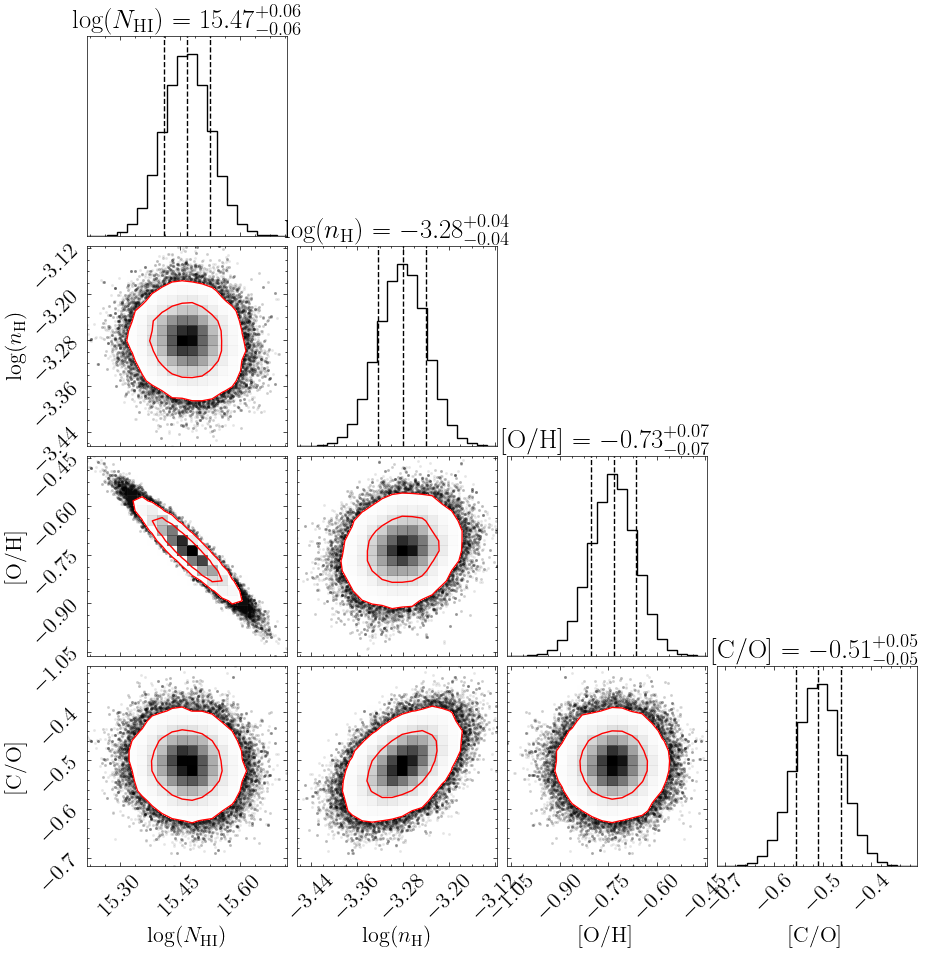

In [65]:
fig = corner.corner(
    flat_samples_hyd_oxy_sul_carb, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_\mathrm{HI})$', r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', r'$[\mathrm{C/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [66]:
logN_dict = {'HI':'15.44, -0.06, +0.06',
            'CII':'<13.2',
            'CIII':'13.97, -0.05, +0.05',
            'CIV':'13.68, -0.06, +0.06',
            'NII':'<13.0',
            'NIII':'<13.2',
            'NV':'<13.5',
            'OII':'<13.0',
            'OIII':'14.42, -0.02, +0.02',
            'OIV':'14.99, -0.04, +0.06',
            'NeVIII':'<13.1',
            'MgII':'<11.2',
            'AlIII':'<12.3',
            'SiII':'<13.0',
            'SiIII':'<12.6',
            'SVI':'<12.6',
            'FeII':'<11.6'}

In [67]:
sample_indices_hyd_oxy_sul_carb = np.random.randint(low=0, high=len(flat_samples_hyd_oxy_sul_carb), size=200)

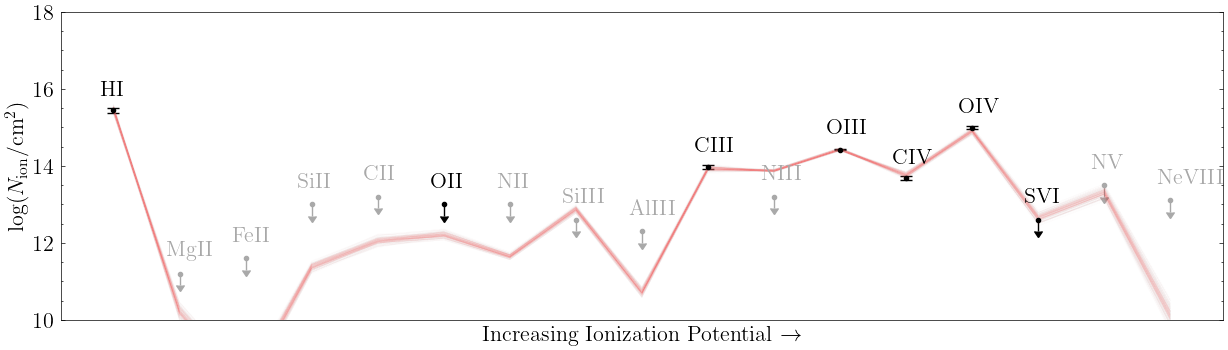

In [68]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['CII',
                                                         'NII', 'NIII', 
                                                         'NV', 
                                                         'NeVIII', 'MgII', 
                                                         'AlIII', 'SiII', 'SiIII', 
                                                         'FeII', 'OVI'])

for i in range(len(sample_indices_hyd_oxy_sul_carb)):
    
    idx = sample_indices_hyd_oxy_sul_carb[i]
    flat_samples_row = flat_samples_hyd_oxy_sul_carb.iloc[i]
    logN_HI = flat_samples_row['logN_HI']
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    C_O = flat_samples_row['C_O']
    
    logN_species_test = predict_col_dens(logN_dict, logN_HI, log_hdens, 
                                         log_metals, species_logN_interp, {'C': C_O})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.05)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.33 \pm 0.03$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -0.66 \pm 0.02$')

#plt.savefig(savedir+'z=0_67532051_cloudy_oxy_sul.pdf', dpi=300)